In [6]:
"""
Giulia D'Angelo, giulia.dangelo@fel.cvut.cz

This script implements a saliency-based attention mechanism using event-driven data.
It processes a series of events representing two objects, visualizing their spatial attention
through a saliency map. The attention mechanism is designed to highlight the most significant
features of the scene, using configurable parameters that define the characteristics of the
attention arcs and kernels.

The script leverages PyTorch for efficient tensor operations and OpenCV for real-time visualization
of the saliency maps. The primary steps include loading event data, initializing the attention
network, and iterating through the events to update and visualize the saliency map in response
to incoming data.

Key components:
- `Config`: A class that holds the parameters for the attention mechanism.
- `initialise_attention`: A helper function to set up the attention network.
- `run_attention`: A function that computes the saliency map based on the current window of events.

This implementation aims to demonstrate how attention mechanisms can be applied to dynamic
visual data, enabling robots and systems to focus on relevant features in real-time.
"""

"\nGiulia D'Angelo, giulia.dangelo@fel.cvut.cz\n\nThis script implements a saliency-based attention mechanism using event-driven data.\nIt processes a series of events representing two objects, visualizing their spatial attention\nthrough a saliency map. The attention mechanism is designed to highlight the most significant\nfeatures of the scene, using configurable parameters that define the characteristics of the\nattention arcs and kernels.\n\nThe script leverages PyTorch for efficient tensor operations and OpenCV for real-time visualization\nof the saliency maps. The primary steps include loading event data, initializing the attention\nnetwork, and iterating through the events to update and visualize the saliency map in response\nto incoming data.\n\nKey components:\n- `Config`: A class that holds the parameters for the attention mechanism.\n- `initialise_attention`: A helper function to set up the attention network.\n- `run_attention`: A function that computes the saliency map base

# Tutorial 5: Event Based Spiking Visual Attention  
When we look at a scene, we do not process everything equally. The brain selectively routes processing resources toward the most relevant regions — a mechanism called __visual attention__. Computationally, this is modelled by computing a __saliency map__: a 2D score over the image where high values indicate regions likely to attract attention.  

The model implemented here is inspired by the proto-object saliency framework (Russell, Alexander et al., Vision Research, 2014), which proposes that early visual processing groups nearby, similar features into coherent regions — proto-objects, or "objects-to-be" — before any recognition takes place. Saliency emerges from competition between these grouped regions.

The implementation uses Von Mises filters: arc-shaped kernels at 8 orientations, analogous to orientation-tuned neurons in the primary visual cortex (V1). These filters are applied across a 6-level spatial pyramid to capture salient structures at multiple scales, and their outputs are summed into a single saliency map. A layer of LIF neurons replaces the static normalisation of the original model, adding temporal integration: rather than computing saliency instantaneously from a frame, the model accumulates evidence from events over time. This makes the pipeline directly compatible with the sparse, asynchronous output of a DVS event camera.


### __Task 1: Apply visual attention to event-based data__  
Run the cell loading the event-based data from .npy file containing x, y coordinates, timestamps t and polarities p.  
Running the attention mechanism cell then initializes the attention network, and returns saliency map for each time window, showing the results interactively.  

Play around with the window_period parameter, why is it used in the attention mechanism, and how does it affect the saliency computation?

In [7]:
import matplotlib.pyplot as plt
import numpy as np
from helpers.helpers import initialise_attention, run_attention
import torch
import cv2
import torchvision

device = torch.device("cuda") if torch.cuda.is_available() else torch.device("mps") if torch.backends.mps.is_available() else torch.device("cpu")

### Load event-based data  
Make sure you have downloaded the data from [dropbox](https://www.dropbox.com/scl/fi/bt7l382p1b7ouau5x07tb/twoobjects.npy?rlkey=w33wyjx3jme95eimjg6srw6u7&st=c99r18fz&dl=0). 

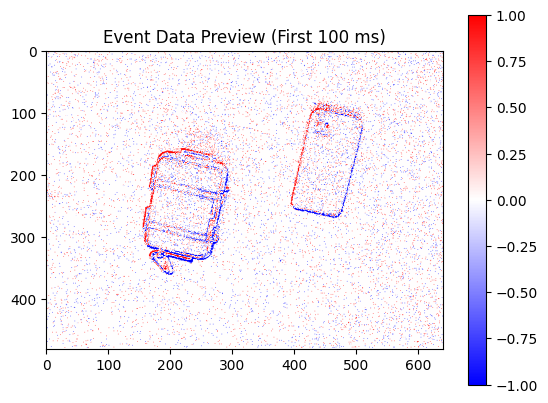

In [8]:
# Load event data from a .npy file containing two objects
data = np.load('data/twoobjects/twoobjects.npy')

# Extract coordinates and properties from the data
x, y, p, t = data[:, 0].astype(int), data[:, 1].astype(int), data[:, 2], data[:, 3] * 1e3

# Determine the resolution based on the maximum coordinates
max_x = x.max() + 1  # Maximum x coordinate + 1 for resolution
max_y = y.max() + 1  # Maximum y coordinate + 1 for resolution
resolution = (max_y, max_x)  # Resolution tuple for attention processing

# QUickly visualize the first 100ms of the events
m = (t >= t[0]) & (t < t[0] + 100)
preview = np.zeros((max_y, max_x))
preview[y[m], x[m]] = np.where(p[m] > 0, 1, -1) # Vectorized insertion of polarity (+1 for ON, -1 for OFF)
plt.imshow(preview, cmap='bwr', vmin=-1, vmax=1); plt.title("Event Data Preview (First 100 ms)"); plt.colorbar(); plt.show()

### Apply attention mechanism

In [ ]:
# Configuration class to store attention parameters
class Config:
    # Attention Parameters
    ATTENTION_PARAMS = {
        'size_krn': 16,  # Size of the kernel used in the attention mechanism
        'r0': 14,  # Radius shift from the center for the attention arc
        'rho': 0.05,  # Scale coefficient to control the arc length
        'theta': np.pi * 3 / 2,  # Angle to control the orientation of the arc
        'thetas': np.arange(0, 2 * np.pi, np.pi / 4),  # Array of angles for multi-directional attention
        'thick': 3,  # Thickness of the arc in the attention map
        'fltr_resize_perc': [2, 2],  # Resize percentage for filters
        'offsetpxs': 0,  # Offset in pixels (half the size of the kernel)
        'offset': (0, 0),  # Offset for attention positioning
        'num_pyr': 6,  # Number of pyramid levels in the attention network
        'tau_mem': 0.3,  # Memory time constant for the attention mechanism
        'stride': 1,  # Stride for attention processing
        'out_ch': 1  # Number of output channels
    }

# Initialize the configuration
config = Config()

# Initialize saliency map and coordinates for maximum saliency
saliency_map = np.zeros((max_y, max_x), dtype=np.float32)  # Saliency map initialized to zero
salmax_coords = np.zeros((2,), dtype=np.int32)  # Array to hold coordinates of maximum saliency

##### Attention Mechanism #####
# Initialize the attention modules with the specified device and parameters
net_attention = initialise_attention(device, config.ATTENTION_PARAMS)

# Set the time window period for processing events (in milliseconds)
window_period = 100  # Time window in milliseconds
time = window_period  # Initialize the time variable
window = torch.zeros((1, max_y, max_x), dtype=torch.float32)  # Create a tensor to hold the current window of events

# Iterate through the event data
for xi, yi, pi, ti in zip(x, y, p, t):
    if ti <= time:
        # If the event time is within the current time window, update the window
        window[0][yi][xi] = 255  # Mark the pixel corresponding to the event
    else:
        # If the event time exceeds the current time window, process the attention
        saliency_map[:], salmax_coords[:] = run_attention(window, net_attention, device, resolution,
                                                          config.ATTENTION_PARAMS['num_pyr'])

        # PLOTS
        # Apply a color map to the window for better visualization
        window_map_jet = cv2.applyColorMap(window.detach().cpu().numpy().squeeze(0).astype(np.uint8), cv2.COLORMAP_JET)
        
        # Add labels and draw a circle at the location of maximum saliency
        cv2.putText(window_map_jet, 'Events map', (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 1,
                    (0, 0, 255), 2, cv2.LINE_AA)
        cv2.circle(window_map_jet, (int(salmax_coords[1]), int(salmax_coords[0])), 6, (255, 255, 255), 4)

        # Normalize the saliency map to 8-bit [0, 255] and apply a colormap
        sal_normalized = cv2.normalize(saliency_map, None, 0, 255, cv2.NORM_MINMAX, dtype=cv2.CV_8U)
        saliency_map_color = cv2.applyColorMap(sal_normalized, cv2.COLORMAP_JET)
        
        # Add labels and draw a circle at the location of maximum saliency
        cv2.putText(saliency_map_color, 'Saliency map', (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 1,
                    (255, 0, 0), 2, cv2.LINE_AA)
        cv2.circle(saliency_map_color, (int(salmax_coords[1]), int(salmax_coords[0])), 6, (255, 255, 255), 4)
        
        # Horizontally concatenate the original events map and the saliency map
        side_by_side = cv2.hconcat([window_map_jet, saliency_map_color])

        # Display the side-by-side visualization
        cv2.imshow('Events and Saliency Map', side_by_side)

        # Wait for a key press to update the display
        cv2.waitKey(1)

        # Increment the time by the window period for the next iteration
        time += window_period

        # Reset the window for the next time period
        window = torch.zeros((1, max_y, max_x), dtype=torch.float32)

# Clean up by closing the OpenCV window after processing all events
cv2.destroyAllWindows()


### __Task 2: Inhibition of return__  
The resulting most salient point can be used for example for selection of smaller regions of interest for further visual processing. If we want to explore the whole object, not only the most salient part, we need to ensure that we don't revisit the already visited locations.  

Your task is to adapt the run_attention function to ensure inhibition of return to already visited locations. Use the templates below.  
You will need to store coordinates of already visited locations and then pass them to run_attention_inhibition_of_return() function. Within the run_attention_function mask out the saliency map so that a circle of radius 30 px is zeroed out around each visited location.

What are the coordinates of the first three detected most salient points when the inhibition of return is active? 

In [ ]:
def run_attention_inhibition_of_return(window, net, device, resolution, num_pyr, visited_locations):
    # Create resized versions of the frames
    resized_frames = [torchvision.transforms.Resize((int(resolution[0] / num_pyr), int(resolution[1] / num_pyr)))(
        window) for pyr in range(1, num_pyr + 1)]

    # Process frames in batches
    batch_frames = torch.stack(
        [torchvision.transforms.Resize((resolution[0], resolution[1]))(window) for window in resized_frames]).type(torch.float32)
    batch_frames = batch_frames.to(device)  # Move to GPU if available
    output_rot = net(batch_frames)
    # Sum the outputs over rotations and scales
    output_rot_sum = torch.sum(torch.sum(output_rot, dim=1, keepdim=True), dim=0, keepdim=True).type(torch.float32).cpu().detach()
    salmap = torchvision.transforms.Resize((resolution[0], resolution[1]))(output_rot_sum).squeeze(0).squeeze(
        0)
    
    #TODO  Mask out the saliency map (= 0) to ignore already visited locations
    
    salmax_coords = np.unravel_index(torch.argmax(salmap).cpu().numpy(), salmap.shape)
    # normalise salmap for visualization
    salmap = salmap.detach().cpu().numpy()
    salmap = np.array((salmap - salmap.min()) / (salmap.max() - salmap.min()) * 255)
    return salmap, salmax_coords

In [ ]:
# Configuration class to store attention parameters
class Config:
    # Attention Parameters
    ATTENTION_PARAMS = {
        'size_krn': 16,  # Size of the kernel used in the attention mechanism
        'r0': 14,  # Radius shift from the center for the attention arc
        'rho': 0.05,  # Scale coefficient to control the arc length
        'theta': np.pi * 3 / 2,  # Angle to control the orientation of the arc
        'thetas': np.arange(0, 2 * np.pi, np.pi / 4),  # Array of angles for multi-directional attention
        'thick': 3,  # Thickness of the arc in the attention map
        'fltr_resize_perc': [2, 2],  # Resize percentage for filters
        'offsetpxs': 0,  # Offset in pixels (half the size of the kernel)
        'offset': (0, 0),  # Offset for attention positioning
        'num_pyr': 6,  # Number of pyramid levels in the attention network
        'tau_mem': 0.3,  # Memory time constant for the attention mechanism
        'stride': 1,  # Stride for attention processing
        'out_ch': 1  # Number of output channels
    }

# Initialize saliency map and coordinates for maximum saliency
saliency_map = np.zeros((max_y, max_x), dtype=np.float32)  # Saliency map initialized to zero
salmax_coords = np.zeros((2,), dtype=np.int32)  # Array to hold coordinates of maximum saliency

##### Attention Mechanism #####
# Initialize the attention modules with the specified device and parameters
net_attention = initialise_attention(device, config.ATTENTION_PARAMS)

# Set the time window period for processing events (in milliseconds)
window_period = 100  # Time window in milliseconds
time = window_period  # Initialize the time variable
window = torch.zeros((1, max_y, max_x), dtype=torch.float32)  # Create a tensor to hold the current window of events

visited_locations = []

# Iterate through the event data
for xi, yi, pi, ti in zip(x, y, p, t):
    if ti <= time:
        # If the event time is within the current time window, update the window
        window[0][yi][xi] = 255  # Mark the pixel corresponding to the event
    else:

        #TODO: Here use the run_attention_inhibition_of_return(window, net_attention, device, resolution,
        #                                   config.ATTENTION_PARAMS['num_pyr'], visited_locations) 
        #      function instead of run_attention()
        saliency_map[:], salmax_coords[:] = pass
       
        # Apply a color map to the window for better visualization
        window_map_jet = cv2.applyColorMap(window.detach().cpu().numpy().squeeze(0).astype(np.uint8), cv2.COLORMAP_JET)
        
        # Add labels and draw a circle at the location of maximum saliency
        cv2.putText(window_map_jet, 'Events map', (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 1,
                    (0, 0, 255), 2, cv2.LINE_AA)
        cv2.circle(window_map_jet, (int(salmax_coords[1]), int(salmax_coords[0])), 6, (255, 255, 255), 4)

        # --- 2) Prepare the Saliency Map ---
        # Normalize the saliency map to 8-bit [0, 255] and apply a colormap
        sal_normalized = cv2.normalize(saliency_map, None, 0, 255, cv2.NORM_MINMAX, dtype=cv2.CV_8U)
        saliency_map_color = cv2.applyColorMap(sal_normalized, cv2.COLORMAP_JET)
        
        # Add labels and draw a circle at the location of maximum saliency
        cv2.putText(saliency_map_color, 'Saliency map', (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 1,
                    (255, 0, 0), 2, cv2.LINE_AA)
        cv2.circle(saliency_map_color, (int(salmax_coords[1]), int(salmax_coords[0])), 6, (255, 255, 255), 4)
        
        # --- 3) Concatenate and Show ---
        # Horizontally concatenate the original events map and the saliency map
        side_by_side = cv2.hconcat([window_map_jet, saliency_map_color])

        # Display the side-by-side visualization
        cv2.imshow('Events and Saliency Map', side_by_side)

        # Wait for a key press to update the display
        cv2.waitKey(1)

        # Increment the time by the window period for the next iteration
        time += window_period

        # Reset the window for the next time period
        window = torch.zeros((1, max_y, max_x), dtype=torch.float32)

# Clean up by closing the OpenCV window after processing all events
cv2.destroyAllWindows()


Solution

In [ ]:
def run_attention_inhibition_of_return(window, net, device, resolution, num_pyr, visited_locations):
    # Create resized versions of the frames
    resized_frames = [torchvision.transforms.Resize((int(resolution[0] / num_pyr), int(resolution[1] / num_pyr)))(
        window) for pyr in range(1, num_pyr + 1)]

    # Process frames in batches
    batch_frames = torch.stack(
        [torchvision.transforms.Resize((resolution[0], resolution[1]))(window) for window in resized_frames]).type(torch.float32)
    batch_frames = batch_frames.to(device)  # Move to GPU if available
    output_rot = net(batch_frames)
    # Sum the outputs over rotations and scales
    output_rot_sum = torch.sum(torch.sum(output_rot, dim=1, keepdim=True), dim=0, keepdim=True).type(torch.float32).cpu().detach()
    salmap = torchvision.transforms.Resize((resolution[0], resolution[1]))(output_rot_sum).squeeze(0).squeeze(
        0)
    
    #TODO  Mask out the saliency map to ignore already visited locations
    radius = 30
    for y, x in visited_locations:
        salmap_np = salmap.numpy()
        cv2.circle(salmap_np, (x, y), radius, 0, -1)
        salmap = torch.from_numpy(salmap_np)


    salmax_coords = np.unravel_index(torch.argmax(salmap).cpu().numpy(), salmap.shape)
    # normalise salmap for visualization
    salmap = salmap.detach().cpu().numpy()
    salmap = np.array((salmap - salmap.min()) / (salmap.max() - salmap.min()) * 255)
    return salmap, salmax_coords

In [ ]:
# Configuration class to store attention parameters
class Config:
    # Attention Parameters
    ATTENTION_PARAMS = {
        'size_krn': 16,  # Size of the kernel used in the attention mechanism
        'r0': 14,  # Radius shift from the center for the attention arc
        'rho': 0.05,  # Scale coefficient to control the arc length
        'theta': np.pi * 3 / 2,  # Angle to control the orientation of the arc
        'thetas': np.arange(0, 2 * np.pi, np.pi / 4),  # Array of angles for multi-directional attention
        'thick': 3,  # Thickness of the arc in the attention map
        'fltr_resize_perc': [2, 2],  # Resize percentage for filters
        'offsetpxs': 0,  # Offset in pixels (half the size of the kernel)
        'offset': (0, 0),  # Offset for attention positioning
        'num_pyr': 6,  # Number of pyramid levels in the attention network
        'tau_mem': 0.3,  # Memory time constant for the attention mechanism
        'stride': 1,  # Stride for attention processing
        'out_ch': 1  # Number of output channels
    }

# Initialize saliency map and coordinates for maximum saliency
saliency_map = np.zeros((max_y, max_x), dtype=np.float32)  # Saliency map initialized to zero
salmax_coords = np.zeros((2,), dtype=np.int32)  # Array to hold coordinates of maximum saliency

##### Attention Mechanism #####
# Initialize the attention modules with the specified device and parameters
net_attention = initialise_attention(device, config.ATTENTION_PARAMS)

# Set the time window period for processing events (in milliseconds)
window_period = 100  # Time window in milliseconds
time = window_period  # Initialize the time variable
window = torch.zeros((1, max_y, max_x), dtype=torch.float32)  # Create a tensor to hold the current window of events

visited_locations = []

# Iterate through the event data
for xi, yi, pi, ti in zip(x, y, p, t):
    if ti <= time:
        # If the event time is within the current time window, update the window
        window[0][yi][xi] = 255  # Mark the pixel corresponding to the event
    else:
        # If the event time exceeds the current time window, process the attention
        saliency_map[:], salmax_coords[:] = run_attention_inhibition_of_return(window, net_attention, device, resolution,
                                                          config.ATTENTION_PARAMS['num_pyr'], visited_locations)

        visited_locations.append((salmax_coords[0], salmax_coords[1]))  # Add the current maximum saliency location to visited locations
        print(salmax_coords)
        # --- 1) Prepare the Event Window Map ---
        # Apply a color map to the window for better visualization
        window_map_jet = cv2.applyColorMap(window.detach().cpu().numpy().squeeze(0).astype(np.uint8), cv2.COLORMAP_JET)
        
        # Add labels and draw a circle at the location of maximum saliency
        cv2.putText(window_map_jet, 'Events map', (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 1,
                    (0, 0, 255), 2, cv2.LINE_AA)
        cv2.circle(window_map_jet, (int(salmax_coords[1]), int(salmax_coords[0])), 6, (255, 255, 255), 4)

        # --- 2) Prepare the Saliency Map ---
        # Normalize the saliency map to 8-bit [0, 255] and apply a colormap
        sal_normalized = cv2.normalize(saliency_map, None, 0, 255, cv2.NORM_MINMAX, dtype=cv2.CV_8U)
        saliency_map_color = cv2.applyColorMap(sal_normalized, cv2.COLORMAP_JET)
        
        # Add labels and draw a circle at the location of maximum saliency
        cv2.putText(saliency_map_color, 'Saliency map', (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 1,
                    (255, 0, 0), 2, cv2.LINE_AA)
        cv2.circle(saliency_map_color, (int(salmax_coords[1]), int(salmax_coords[0])), 6, (255, 255, 255), 4)
        
        # --- 3) Concatenate and Show ---
        # Horizontally concatenate the original events map and the saliency map
        side_by_side = cv2.hconcat([window_map_jet, saliency_map_color])

        # Display the side-by-side visualization
        cv2.imshow('Events and Saliency Map', side_by_side)

        # Wait for a key press to update the display
        cv2.waitKey(1)

        # Increment the time by the window period for the next iteration
        time += window_period

        # Reset the window for the next time period
        window = torch.zeros((1, max_y, max_x), dtype=torch.float32)

# Clean up by closing the OpenCV window after processing all events
cv2.destroyAllWindows()

# First three coordinates: [334 180], [298 264], [246 278]
